<a href="https://colab.research.google.com/github/Gebrhans/maize-disease-detection/blob/main/potatobestcode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# POTATO DISEASE DETECTION USING EFFICIENTNET + GRAD-CAM++
# Dataset Upload from Local Computer (.zip)
# 80% Training, 20% Testing
# Google Colab GPU Version
# ============================================================

# Install Required Packages
!pip install -q tf-keras-vis

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.scores import CategoricalScore

print("TensorFlow Version:", tf.__version__)

# ============================================================
# CHECK GPU
# ============================================================

print("GPU Available:",
      tf.config.list_physical_devices('GPU'))

# ============================================================
# STEP 1: UPLOAD ZIP DATASET
# ============================================================

print("\nUpload potato_dataset.zip")

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

# ============================================================
# STEP 2: EXTRACT DATASET
# ============================================================

extract_path = "/content/potato_dataset"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

# ============================================================
# STEP 3: FIND DATASET DIRECTORY
# ============================================================

dataset_dir = None

for root, dirs, files_ in os.walk(extract_path):
    if len(dirs) >= 2:
        dataset_dir = root
        break

print("Dataset Directory:", dataset_dir)

# ============================================================
# STEP 4: DATA PREPROCESSING
# ============================================================

IMG_SIZE = (224,224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

test_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("\nClasses:")
print(train_generator.class_indices)

# ============================================================
# STEP 5: BUILD EFFICIENTNET MODEL
# ============================================================

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256,
          activation='relu')(x)

x = Dropout(0.4)(x)

outputs = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================================
# STEP 6: TRAIN MODEL
# ============================================================

EPOCHS = 20

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS
)

# ============================================================
# STEP 7: EVALUATION
# ============================================================

loss, accuracy = model.evaluate(test_generator)

print("\nTest Accuracy:", accuracy)

predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

acc = accuracy_score(y_true, y_pred)
prec = precision_score(
    y_true,
    y_pred,
    average='weighted'
)
rec = recall_score(
    y_true,
    y_pred,
    average='weighted'
)
f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("\n==============================")
print("Performance Metrics")
print("==============================")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(
            train_generator.class_indices.keys()
        )
    )
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.colorbar()

plt.xticks(
    np.arange(
        len(train_generator.class_indices)
    ),
    train_generator.class_indices.keys(),
    rotation=45
)

plt.yticks(
    np.arange(
        len(train_generator.class_indices)
    ),
    train_generator.class_indices.keys()
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# TRAINING CURVES
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])

plt.show()

# ============================================================
# SAVE MODEL
# ============================================================

model.save(
    "/content/Potato_EfficientNet_Model.h5"
)

print("Model Saved Successfully")

# ============================================================
# STEP 8: UPLOAD TEST IMAGE
# ============================================================

print("\nUpload Potato Leaf Image")

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# ============================================================
# IMAGE PREPROCESSING
# ============================================================

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

# ============================================================
# PREDICTION
# ============================================================

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

class_names = list(
    train_generator.class_indices.keys()
)

disease = class_names[predicted_class]

confidence = np.max(prediction) * 100

print("\nPrediction :", disease)
print("Confidence :", round(confidence,2),"%")

# ============================================================
# DISPLAY IMAGE
# ============================================================

plt.figure(figsize=(6,6))
plt.imshow(
    image.load_img(
        img_path,
        target_size=(224,224)
    )
)

plt.title(
    f"{disease}\nConfidence:{confidence:.2f}%"
)

plt.axis("off")
plt.show()

# ============================================================
# CLIMATE INPUT
# ============================================================

temperature = float(
    input("Temperature (°C): ")
)

humidity = float(
    input("Humidity (%): ")
)

# ============================================================
# RECOMMENDATION SYSTEM
# ============================================================

def get_recommendation(
        disease,
        temperature,
        humidity):

    if disease.lower() == "early_blight":

        return """
Disease: Early Blight

Treatment:
- Apply Chlorothalonil
- Remove infected leaves
- Practice crop rotation

Climate Advice:
- High temperature favors disease
- Reduce leaf wetness
"""

    elif disease.lower() == "late_blight":

        return """
Disease: Late Blight

Treatment:
- Apply Mancozeb
- Improve drainage
- Remove infected plants

Climate Advice:
- High humidity accelerates spread
"""

    else:

        return """
Healthy Plant

Recommendation:
- Continue monitoring
- Apply balanced fertilizer
- Maintain irrigation
"""

print("\n")
print(
    get_recommendation(
        disease,
        temperature,
        humidity
    )
)

# ============================================================
# STEP 9: GRAD-CAM++
# ============================================================

score = CategoricalScore(
    [predicted_class]
)

gradcam = GradcamPlusPlus(
    model,
    clone=True
)

cam = gradcam(
    score,
    img_array
)

heatmap = cam[0]

# ============================================================
# DISPLAY HEATMAP
# ============================================================

plt.figure(figsize=(8,8))

plt.imshow(
    heatmap,
    cmap='jet'
)

plt.title(
    "Grad-CAM++ Heatmap"
)

plt.axis("off")
plt.show()

# ============================================================
# OVERLAY HEATMAP
# ============================================================

original = image.load_img(
    img_path,
    target_size=(224,224)
)

original = image.img_to_array(
    original
).astype(np.uint8)

heatmap = np.uint8(
    255 * heatmap
)

heatmap_rgb = plt.cm.jet(
    heatmap
)[:,:,:3]

heatmap_rgb = (
    heatmap_rgb * 255
).astype(np.uint8)

overlay = (
    0.6 * original +
    0.4 * heatmap_rgb
)

overlay = overlay.astype(np.uint8)

plt.figure(figsize=(8,8))

plt.imshow(overlay)

plt.title(
    "Grad-CAM++ Explanation"
)

plt.axis("off")
plt.show()

print("\nSystem Completed Successfully")

In [ ]:
# ============================================================
# IMPORT EXTRA LIBRARIES
# ============================================================

from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ============================================================
# DATA AUGMENTATION
# ============================================================

IMG_SIZE = (224,224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20,
    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.20,
    height_shift_range=0.20,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

test_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Classes:")
print(train_generator.class_indices)

# ============================================================
# BUILD EFFICIENTNET
# ============================================================

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(
    512,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

output = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================================
# CALLBACKS
# ============================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# ============================================================
# PHASE 1 TRAINING
# ============================================================

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=15,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

# ============================================================
# PHASE 2 FINE-TUNING
# ============================================================

base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

# ============================================================
# EVALUATION
# ============================================================

loss, accuracy = model.evaluate(
    test_generator
)

print("Accuracy:", accuracy)

predictions = model.predict(
    test_generator
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = test_generator.classes

acc = accuracy_score(
    y_true,
    y_pred
)

prec = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

rec = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("\n===================")
print("RESULTS")
print("===================")

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(
            train_generator.class_indices.keys()
        )
    )
)

In [ ]:
# ============================================================
# MAIZE (CORN) LEAF DISEASE DETECTION USING EFFICIENTNET + GRAD-CAM++
# ============================================================

!pip install -q tf-keras-vis

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.scores import CategoricalScore

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

# ============================================================
# STEP 1: UPLOAD DATASET ZIP
# ============================================================

print("Upload maize_dataset.zip")
uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

# ============================================================
# STEP 2: EXTRACT DATASET
# ============================================================

extract_path = "/content/maize_dataset"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

# ============================================================
# STEP 3: FIND DATASET DIRECTORY
# ============================================================

dataset_dir = None
for root, dirs, files_ in os.walk(extract_path):
    if len(dirs) >= 2:
        dataset_dir = root
        break

print("Dataset directory:", dataset_dir)

# ============================================================
# STEP 4: DATA PREPROCESSING
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

test_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("\nClasses:", train_generator.class_indices)

# ============================================================
# STEP 5: BUILD MODEL (EFFICIENTNET)
# ============================================================

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

outputs = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================================
# STEP 6: TRAIN MODEL
# ============================================================

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20
)

# ============================================================
# STEP 7: EVALUATION
# ============================================================

loss, accuracy = model.evaluate(test_generator)
print("\nTest Accuracy:", accuracy)

predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print("\nAccuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(train_generator.class_indices.keys())
))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(train_generator.class_indices)), train_generator.class_indices.keys(), rotation=45)
plt.yticks(range(len(train_generator.class_indices)), train_generator.class_indices.keys())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# TRAINING CURVE
# ============================================================

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['Train','Validation'])
plt.show()

# ============================================================
# SAVE MODEL
# ============================================================

model.save("/content/Maize_EfficientNet_Model.h5")
print("Model saved successfully")

# ============================================================
# STEP 8: IMAGE PREDICTION
# ============================================================

print("Upload maize leaf image")
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

pred_class = np.argmax(prediction)
class_names = list(train_generator.class_indices.keys())

disease = class_names[pred_class]
confidence = np.max(prediction)*100

print("Prediction:", disease)
print("Confidence:", confidence)

plt.imshow(image.load_img(img_path))
plt.title(disease)
plt.axis("off")
plt.show()

# ============================================================
# CLIMATE INPUT + RECOMMENDATION
# ============================================================

temperature = float(input("Temperature (°C): "))
humidity = float(input("Humidity (%): "))

def recommend(disease, temp, hum):

    if disease == "Blight":
        return f"Blight disease detected. Apply fungicide. Temp:{temp}, Hum:{hum}"

    elif disease == "Common_Rust":
        return f"Rust disease detected. Use resistant varieties. Temp:{temp}, Hum:{hum}"

    elif disease == "Gray_Leaf_Spot":
        return f"Gray Leaf Spot detected. Improve field hygiene. Temp:{temp}, Hum:{hum}"

    else:
        return "Healthy maize plant."

print("\nRecommendation:")
print(recommend(disease, temperature, humidity))

# ============================================================
# GRAD-CAM++
# ============================================================

score = CategoricalScore([pred_class])

gradcam = GradcamPlusPlus(model, clone=True)

cam = gradcam(score, img_array)

heatmap = cam[0]

plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM++ Heatmap")
plt.axis("off")
plt.show()

# Overlay
img_original = image.img_to_array(image.load_img(img_path, target_size=(224,224)))

heatmap = np.uint8(255 * heatmap)
heatmap = plt.cm.jet(heatmap)[:,:,:3]
heatmap = (heatmap * 255).astype(np.uint8)

overlay = (0.6 * img_original + 0.4 * heatmap).astype(np.uint8)

plt.imshow(overlay)
plt.title("Grad-CAM++ Explanation")
plt.axis("off")
plt.show()

print("DONE 🚀 Maize Disease System Complete")

In [ ]:
# ============================================================
# MAIZE LEAF DISEASE DETECTION (EfficientNet + CBAM + Grad-CAM++)
# ============================================================

!pip install -q tf-keras-vis

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
import tensorflow as tf

# ✔ FIX: modern imports (NO "image" import anymore)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.scores import CategoricalScore

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

# ============================================================
# STEP 1: UPLOAD DATASET
# ============================================================

print("Upload maize_dataset.zip")
uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

# ============================================================
# STEP 2: EXTRACT DATASET
# ============================================================

extract_path = "/content/maize_dataset"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted")

# Find dataset directory
dataset_dir = None
for root, dirs, files_ in os.walk(extract_path):
    if len(dirs) >= 2:
        dataset_dir = root
        break

print("Dataset directory:", dataset_dir)

# ============================================================
# STEP 3: DATA PREPROCESSING
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

test_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Classes:", train_generator.class_indices)

# ============================================================
# STEP 4: CBAM ATTENTION BLOCK
# ============================================================

def cbam_block(inputs, ratio=8):

    channel = inputs.shape[-1]

    # Channel Attention
    avg_pool = GlobalAveragePooling2D()(inputs)
    max_pool = GlobalMaxPooling2D()(inputs)

    dense1 = Dense(channel // ratio, activation='relu')
    dense2 = Dense(channel)

    avg = dense2(dense1(Reshape((1,1,channel))(avg_pool)))
    max = dense2(dense1(Reshape((1,1,channel))(max_pool)))

    channel_attention = Activation('sigmoid')(Add()([avg, max]))
    x = Multiply()([inputs, channel_attention])

    # Spatial Attention
    avg_pool_spatial = tf.reduce_mean(x, axis=-1, keepdims=True)
    max_pool_spatial = tf.reduce_max(x, axis=-1, keepdims=True)

    concat = Concatenate()([avg_pool_spatial, max_pool_spatial])

    spatial_attention = Conv2D(1, 7, padding='same', activation='sigmoid')(concat)

    return Multiply()([x, spatial_attention])

# ============================================================
# STEP 5: MODEL (EfficientNet + CBAM)
# ============================================================

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = cbam_block(x)

x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

outputs = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================================
# STEP 6: TRAINING (PHASE 1)
# ============================================================

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=15
)

# ============================================================
# STEP 7: FINE-TUNING (IMPORTANT)
# ============================================================

base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

# ============================================================
# STEP 8: EVALUATION
# ============================================================

pred = model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes

print("\nAccuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(train_generator.class_indices.keys())
))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(train_generator.class_indices)), train_generator.class_indices.keys(), rotation=45)
plt.yticks(range(len(train_generator.class_indices)), train_generator.class_indices.keys())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# SAVE MODEL
# ============================================================

model.save("/content/Maize_CBAM_Model.h5")
print("Model saved successfully")

# ============================================================
# STEP 9: PREDICTION
# ============================================================

print("Upload maize leaf image")
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = load_img(img_path, target_size=(224,224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

pred_class = np.argmax(prediction)
class_names = list(train_generator.class_indices.keys())

disease = class_names[pred_class]
confidence = np.max(prediction) * 100

print("Prediction:", disease)
print("Confidence:", confidence)

plt.imshow(load_img(img_path))
plt.title(disease)
plt.axis("off")
plt.show()

# ============================================================
# CLIMATE RECOMMENDATION
# ============================================================

temp = float(input("Temperature (°C): "))
hum = float(input("Humidity (%): "))

def recommend(disease, t, h):

    if disease == "Blight":
        return f"Apply fungicide. Temp:{t}, Hum:{h}"

    elif disease == "Common_Rust":
        return f"Use resistant variety. Temp:{t}, Hum:{h}"

    elif disease == "Gray_Leaf_Spot":
        return f"Improve field hygiene. Temp:{t}, Hum:{h}"

    else:
        return "Healthy maize plant"

print(recommend(disease, temp, hum))

# ============================================================
# STEP 10: GRAD-CAM++
# ============================================================

score = CategoricalScore([pred_class])

gradcam = GradcamPlusPlus(model, clone=True)

cam = gradcam(score, img_array)

heatmap = cam[0]

plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM++")
plt.axis("off")
plt.show()

# Overlay
orig = img_to_array(load_img(img_path, target_size=(224,224)))

heatmap = np.uint8(255 * heatmap)
heatmap = plt.cm.jet(heatmap)[:,:,:3]
heatmap = (heatmap * 255).astype(np.uint8)

overlay = (0.6 * orig + 0.4 * heatmap).astype(np.uint8)

plt.imshow(overlay)
plt.title("Explainable AI (CBAM + Grad-CAM++)")
plt.axis("off")
plt.show()

print("DONE 🚀 Maize Disease System Ready")

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Upload maize_dataset.zip


Saving maize.zip to maize.zip
Dataset extracted
Dataset directory: /content/maize_dataset/maize
Found 3352 images belonging to 4 classes.
Found 836 images belonging to 4 classes.
Classes: {'Blight': 0, 'Common_Rust': 1, 'Gray_Leaf_Spot': 2, 'Healthy': 3}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,789,674 (18.27 MB)

 Trainable params: 740,103 (2.82 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 83s 486ms/step - accuracy: 0.3004 - loss: 1.3531 - val_accuracy: 0.3122 - val_loss: 1.3464
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - accuracy: 0.2965 - loss: 1.3520 - val_accuracy: 0.3122 - val_loss: 1.3462
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - accuracy: 0.3082 - loss: 1.3501 - val_accuracy: 0.3122 - val_loss: 1.3456
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - accuracy: 0.3037 - loss: 1.3486 - val_accuracy: 0.3122 - val_loss: 1.3460
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - accuracy: 0.3061 - loss: 1.3479 - val_accuracy: 0.3122 - val_loss: 1.3481
Epoch 6/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - accuracy: 0.3022 - loss: 1.3498 - val_accuracy: 0.3122 - val_loss: 1.3454
Epoch 7/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step - accuracy: 0.3103 - loss: 1.3493 - val_accuracy: 0.3122 - val_loss: 1.3452
Epoch 8/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.3049 - loss: 1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

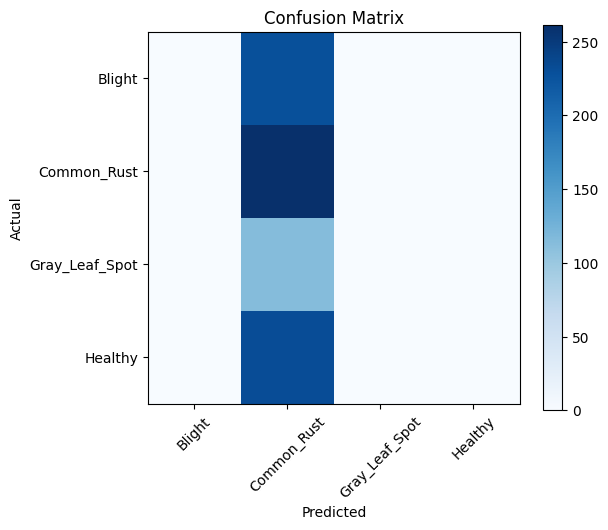

Model Saved
Upload maize leaf image


Saving Corn_Common_Rust (1).jpg to Corn_Common_Rust (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Prediction: Common_Rust
Confidence: 27.621227


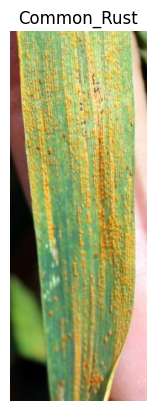

Temperature (°C): 30
Humidity (%): 500
Use resistant varieties. Temp:30.0, Hum:500.0


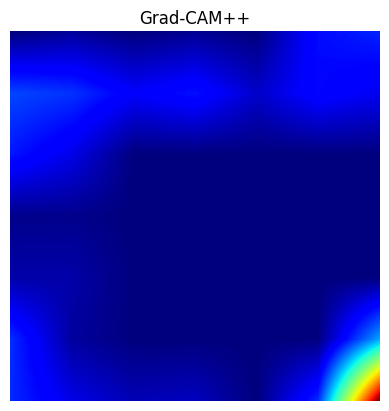

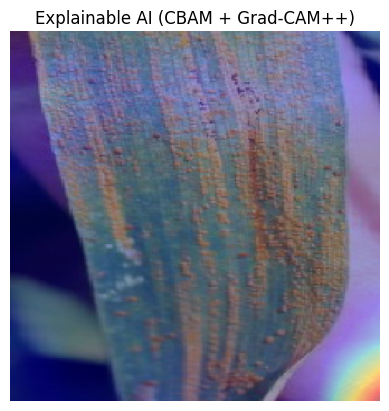

DONE 🚀 Maize CBAM System Ready


In [ ]:
# ============================================================
# MAIZE DISEASE DETECTION (EfficientNet + CBAM + Grad-CAM++)
# FIXED FOR TENSORFLOW 2.20 / KERAS 3
# ============================================================

!pip install -q tf-keras-vis

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
import tensorflow as tf

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.scores import CategoricalScore

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

# ============================================================
# STEP 1: UPLOAD DATASET
# ============================================================

print("Upload maize_dataset.zip")
uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

# ============================================================
# STEP 2: EXTRACT DATASET
# ============================================================

extract_path = "/content/maize_dataset"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted")

# find dataset folder
dataset_dir = None
for root, dirs, files_ in os.walk(extract_path):
    if len(dirs) >= 2:
        dataset_dir = root
        break

print("Dataset directory:", dataset_dir)

# ============================================================
# STEP 3: DATA LOADING
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

test_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Classes:", train_generator.class_indices)

# ============================================================
# STEP 4: CBAM (FIXED KERAS LAYER)
# ============================================================

class CBAM(Layer):
    def __init__(self, ratio=8):
        super(CBAM, self).__init__()
        self.ratio = ratio

    def build(self, input_shape):
        channel = input_shape[-1]

        self.dense1 = Dense(channel // self.ratio, activation='relu')
        self.dense2 = Dense(channel)
        self.conv_spatial = Conv2D(1, 7, padding='same', activation='sigmoid')

    def call(self, inputs):

        channel = inputs.shape[-1]

        # Channel Attention
        avg_pool = GlobalAveragePooling2D()(inputs)
        max_pool = GlobalMaxPooling2D()(inputs)

        avg_pool = Reshape((1,1,channel))(avg_pool)
        max_pool = Reshape((1,1,channel))(max_pool)

        avg = self.dense2(self.dense1(avg_pool))
        max = self.dense2(self.dense1(max_pool))

        channel_attention = Activation('sigmoid')(Add()([avg, max]))
        x = Multiply()([inputs, channel_attention])

        # Spatial Attention (SAFE FIX)
        avg_pool_spatial = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
        max_pool_spatial = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)

        concat = Concatenate()([avg_pool_spatial, max_pool_spatial])

        spatial_attention = self.conv_spatial(concat)

        return Multiply()([x, spatial_attention])

# ============================================================
# STEP 5: MODEL BUILDING
# ============================================================

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = CBAM()(x)

x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

outputs = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================================
# STEP 6: TRAINING PHASE 1
# ============================================================

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=15
)

# ============================================================
# STEP 7: FINE TUNING
# ============================================================

base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

# ============================================================
# STEP 8: EVALUATION
# ============================================================

pred = model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes

print("\nAccuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1:", f1_score(y_true, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(train_generator.class_indices.keys())
))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(train_generator.class_indices)), train_generator.class_indices.keys(), rotation=45)
plt.yticks(range(len(train_generator.class_indices)), train_generator.class_indices.keys())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# SAVE MODEL
# ============================================================

model.save("/content/Maize_CBAM_Model.h5")
print("Model Saved")

# ============================================================
# STEP 9: PREDICTION
# ============================================================

print("Upload maize leaf image")
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = load_img(img_path, target_size=(224,224))
img_array = img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

pred_class = np.argmax(prediction)
class_names = list(train_generator.class_indices.keys())

disease = class_names[pred_class]
confidence = np.max(prediction)*100

print("Prediction:", disease)
print("Confidence:", confidence)

plt.imshow(load_img(img_path))
plt.title(disease)
plt.axis("off")
plt.show()

# ============================================================
# CLIMATE RECOMMENDATION
# ============================================================

temp = float(input("Temperature (°C): "))
hum = float(input("Humidity (%): "))

def recommend(disease, t, h):

    if disease == "Blight":
        return f"Apply fungicide. Temp:{t}, Hum:{h}"

    elif disease == "Common_Rust":
        return f"Use resistant varieties. Temp:{t}, Hum:{h}"

    elif disease == "Gray_Leaf_Spot":
        return f"Improve field hygiene. Temp:{t}, Hum:{h}"

    else:
        return "Healthy maize plant"

print(recommend(disease, temp, hum))

# ============================================================
# STEP 10: GRAD-CAM++
# ============================================================

score = CategoricalScore([pred_class])

gradcam = GradcamPlusPlus(model, clone=True)

cam = gradcam(score, img_array)

heatmap = cam[0]

plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM++")
plt.axis("off")
plt.show()

orig = img_to_array(load_img(img_path, target_size=(224,224)))

heatmap = np.uint8(255 * heatmap)
heatmap = plt.cm.jet(heatmap)[:,:,:3]
heatmap = (heatmap * 255).astype(np.uint8)

overlay = (0.6 * orig + 0.4 * heatmap).astype(np.uint8)

plt.imshow(overlay)
plt.title("Explainable AI (CBAM + Grad-CAM++)")
plt.axis("off")
plt.show()

print("DONE 🚀 Maize CBAM System Ready")